## Problem Statement:Segment the customers based on Age, Annual income, spending score
Our company's goal is to identify the customer groups for personalized target marketing



In [14]:
## Import libraries


import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [15]:
## Load the dataset

df = pd.read_csv("/content/Mall_Customers.csv")

In [16]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [17]:
# Basic data check

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [18]:
df.shape

(200, 5)

In [19]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


In [21]:
df.drop("CustomerID", axis = 1, inplace = True)

In [22]:
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [23]:
## Null value check

df.isnull().sum()

,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [24]:
## Duplicate check

df.duplicated().sum()

np.int64(0)

In [25]:
le = LabelEncoder()

In [26]:
df['Gender'] = le.fit_transform(df['Gender'])

In [27]:
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
...,...,...,...,...
195,0,35,120,79
196,0,45,126,28
197,1,32,126,74
198,1,32,137,18


In [28]:
## Outlier detection


def outlier_detection(df):
  for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [29]:
df = outlier_detection(df)

In [30]:
df.shape

(200, 4)

## Univariate
## Bivariate

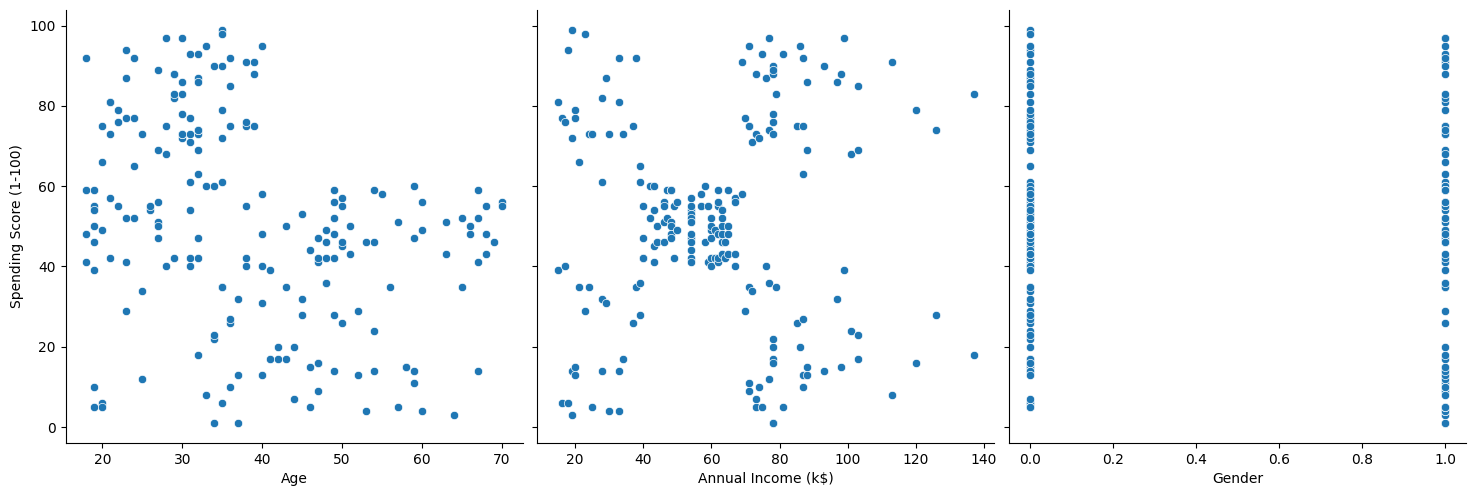

In [31]:
sns.pairplot(df, x_vars= ['Age', 'Annual Income (k$)', 'Gender'], y_vars= 'Spending Score (1-100)',height=5, aspect=1 )

From the above pairplot, it is evident that we see a pattern between:

1.Spending score vs Age
2.Spending score vs Annual Income

## Lets first form clusters based on Spending score vs Annual Income

In [32]:
X = df[['Age','Spending Score (1-100)']]

In [33]:
X

,Age,Spending Score (1-100)
0,19,39
1,21,81
2,20,6
3,23,77
4,31,40
...,...,...
195,35,79
196,45,28
197,32,74
198,32,18


In [34]:
km = KMeans(n_clusters=7) ## Forming cluster with the random value

In [35]:
km

KMeans(n_clusters=7)

## We get 2 parameters for the Kmeans models i.e.
1. km.inertia_ = SSE of that model
2. km.cluster_centers = Stores the values of centroids

In [36]:
y_pred = km.fit_predict(X)

In [37]:
y_pred

array([6, 3, 4, 3, 6, 3, 4, 0, 2, 3, 2, 0, 2, 3, 4, 3, 1, 3, 1, 0, 1, 3,
       2, 3, 2, 0, 1, 3, 1, 0, 2, 3, 2, 0, 2, 3, 4, 3, 4, 3, 5, 0, 1, 3,
       1, 3, 5, 6, 6, 6, 5, 3, 6, 5, 1, 1, 5, 5, 6, 5, 5, 6, 5, 5, 5, 6,
       1, 5, 6, 6, 5, 1, 5, 5, 5, 6, 1, 1, 6, 1, 5, 6, 5, 1, 6, 1, 5, 6,
       3, 1, 5, 6, 1, 1, 6, 6, 1, 6, 1, 6, 6, 1, 5, 6, 5, 6, 5, 5, 5, 5,
       5, 6, 1, 6, 6, 6, 5, 5, 1, 5, 6, 1, 3, 0, 4, 3, 1, 0, 2, 3, 2, 3,
       6, 3, 4, 0, 2, 3, 4, 3, 2, 0, 6, 0, 4, 0, 1, 3, 4, 0, 4, 0, 2, 3,
       2, 0, 4, 3, 4, 3, 1, 0, 4, 0, 2, 3, 4, 0, 4, 3, 4, 3, 4, 0, 2, 0,
       2, 3, 2, 0, 1, 0, 2, 0, 1, 0, 2, 3, 4, 0, 4, 3, 4, 0, 2, 3, 1, 3,
       4, 0], dtype=int32)

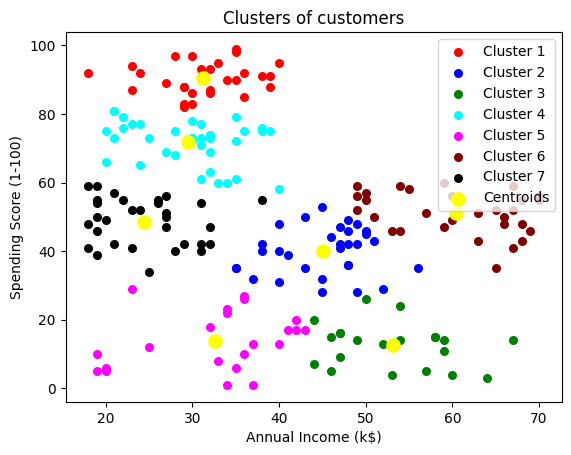

In [38]:
## Lets visualize the output cluster


plt.scatter(X.iloc[y_pred == 0,0], X.iloc[y_pred == 0,1], s = 30, c = 'red', label = 'Cluster 1')
plt.scatter(X.iloc[y_pred == 1,0], X.iloc[y_pred == 1,1], s = 30, c = 'blue', label = 'Cluster 2')
plt.scatter(X.iloc[y_pred == 2,0], X.iloc[y_pred == 2,1], s = 30, c = 'green', label = 'Cluster 3')
plt.scatter(X.iloc[y_pred == 3,0], X.iloc[y_pred == 3,1], s = 30, c = 'cyan', label = 'Cluster 4')
plt.scatter(X.iloc[y_pred == 4,0], X.iloc[y_pred == 4,1], s = 30, c = 'magenta', label = 'Cluster 5')
plt.scatter(X.iloc[y_pred == 5,0], X.iloc[y_pred == 5,1], s = 30, c = 'maroon', label = 'Cluster 6')
plt.scatter(X.iloc[y_pred == 6,0], X.iloc[y_pred == 6,1], s = 30, c = 'black', label = 'Cluster 7')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], s = 90, c = 'yellow', label = 'Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

## Finding the optimal value of K using ELBOW-method

In [39]:
sse = []

In [40]:
for k in range(1,11):
  km = KMeans(n_clusters=k)
  km.fit(X)
  sse.append(km.inertia_)

In [41]:
sse

[171535.50000000003,
 75949.15601023012,
 45840.67661610871,
 28172.705092506112,
 23904.053342829524,
 19764.10311679062,
 17290.742798080126,
 14687.890879530969,
 11520.346107812507,
 10699.066046807224]

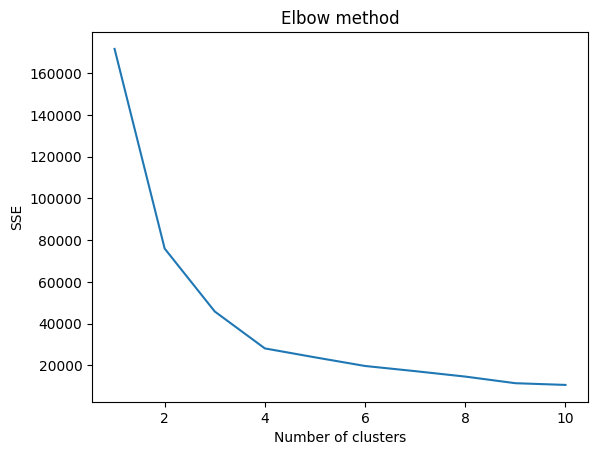

In [42]:
## Lets plot the graph of elbow-chart of K vs SSE

plt.plot(range(1,11), sse)
plt.title("Elbow method")
plt.xlabel("Number of clusters")
plt.ylabel("SSE")
plt.show()

## Optimal value is K=4. lets rebuild the model for K=4

In [43]:
km = KMeans(n_clusters=4) ## Forming cluster with k=5
km

KMeans(n_clusters=4)

In [44]:
y_pred = km.fit_predict(X)

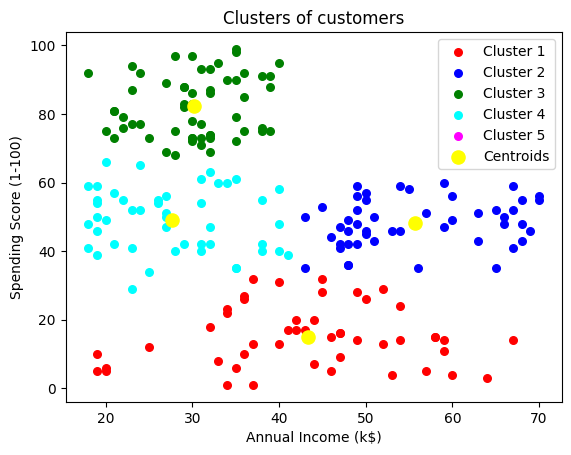

In [45]:
## Lets visualize the output cluster


plt.scatter(X.iloc[y_pred == 0,0], X.iloc[y_pred == 0,1], s = 30, c = 'red', label = 'Cluster 1')
plt.scatter(X.iloc[y_pred == 1,0], X.iloc[y_pred == 1,1], s = 30, c = 'blue', label = 'Cluster 2')
plt.scatter(X.iloc[y_pred == 2,0], X.iloc[y_pred == 2,1], s = 30, c = 'green', label = 'Cluster 3')
plt.scatter(X.iloc[y_pred == 3,0], X.iloc[y_pred == 3,1], s = 30, c = 'cyan', label = 'Cluster 4')
plt.scatter(X.iloc[y_pred == 4,0], X.iloc[y_pred == 4,1], s = 30, c = 'magenta', label = 'Cluster 5')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], s = 90, c = 'yellow', label = 'Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()